(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

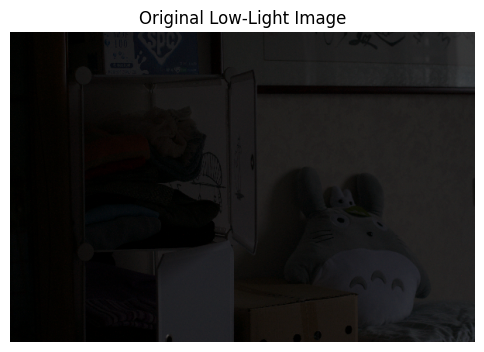

In [77]:
# Step 1: Load the image (update the path after uploading to Kaggle)
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Replace 'your-dataset' and 'low_light.jpg' with your actual dataset name and filename:
img_path = '/kaggle/input/datasets/swadhinpal123/lol-final/22.png'
img_bgr = cv2.imread(img_path)
if img_bgr is None:
    raise FileNotFoundError(f"Image not found at {img_path}. Check the path and Kaggle dataset name.")
# Convert BGR (OpenCV default) to RGB for display
img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Original Low-Light Image")
plt.axis('off')

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

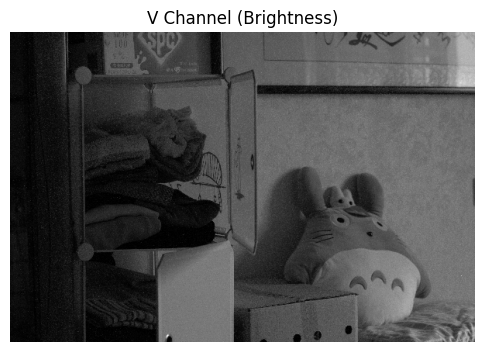

In [78]:
# Step 2: Convert to HSV and extract the V (brightness) channel
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
V = hsv[:, :, 2]

plt.figure(figsize=(6,6))
plt.imshow(V, cmap='gray')
plt.title("V Channel (Brightness)")
plt.axis('off')

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

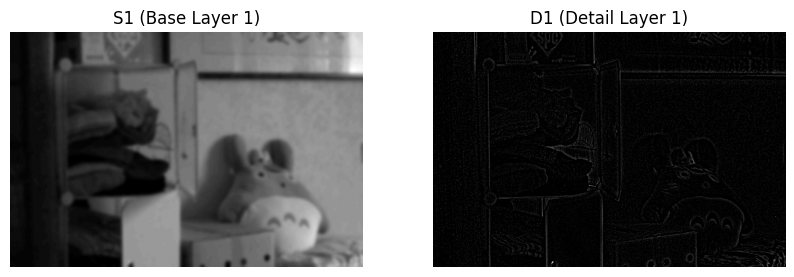

In [79]:
# Step 3: First SSIF decomposition (base S1 and detail D1)
S1 = cv2.GaussianBlur(V, (15, 15), 0)
D1 = cv2.subtract(V, S1)  

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(S1, cmap='gray')
plt.title("S1 (Base Layer 1)")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(D1, cmap='gray')
plt.title("D1 (Detail Layer 1)")
plt.axis('off')

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

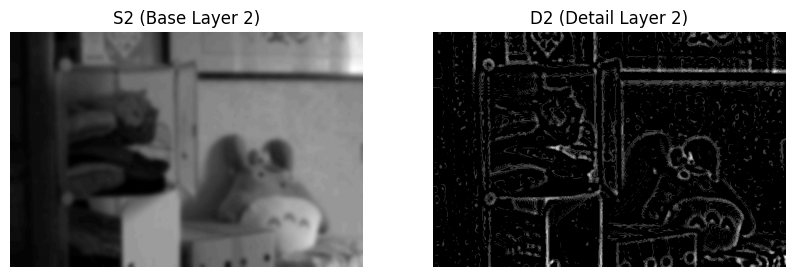

In [80]:
# Step 4: Second SSIF decomposition (base S2 and detail D2)
S2 = cv2.GaussianBlur(S1, (15, 15), 0)
D2 = cv2.subtract(S1, S2)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(S2, cmap='gray')
plt.title("S2 (Base Layer 2)")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(D2, cmap='gray')
plt.title("D2 (Detail Layer 2)")
plt.axis('off')

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

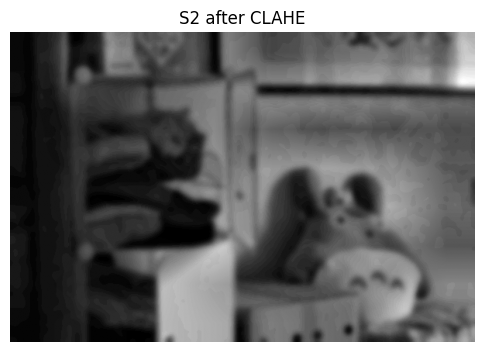

In [81]:
# Step 5: Apply CLAHE to S2
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
S2_clahe = clahe.apply(S2)

plt.figure(figsize=(6,6))
plt.imshow(S2_clahe, cmap='gray')
plt.title("S2 after CLAHE")
plt.axis('off')

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

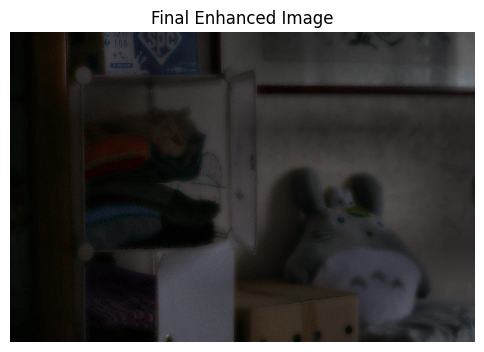

In [82]:
# Step 6: Reconstruct enhanced V and convert back to RGB
# Sum the enhanced base and detail layers (use int type to prevent overflow)
V_enhanced = S2_clahe.astype(np.int16) + D2.astype(np.int16) + D1.astype(np.int16)
V_enhanced = np.clip(V_enhanced, 0, 255).astype(np.uint8)

# Replace the V channel in HSV and convert to RGB
hsv_enhanced = hsv.copy()
hsv_enhanced[:, :, 2] = V_enhanced
enhanced_img = cv2.cvtColor(hsv_enhanced, cv2.COLOR_HSV2RGB)

plt.figure(figsize=(6,6))
plt.imshow(enhanced_img)
plt.title("Final Enhanced Image")
plt.axis('off')

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

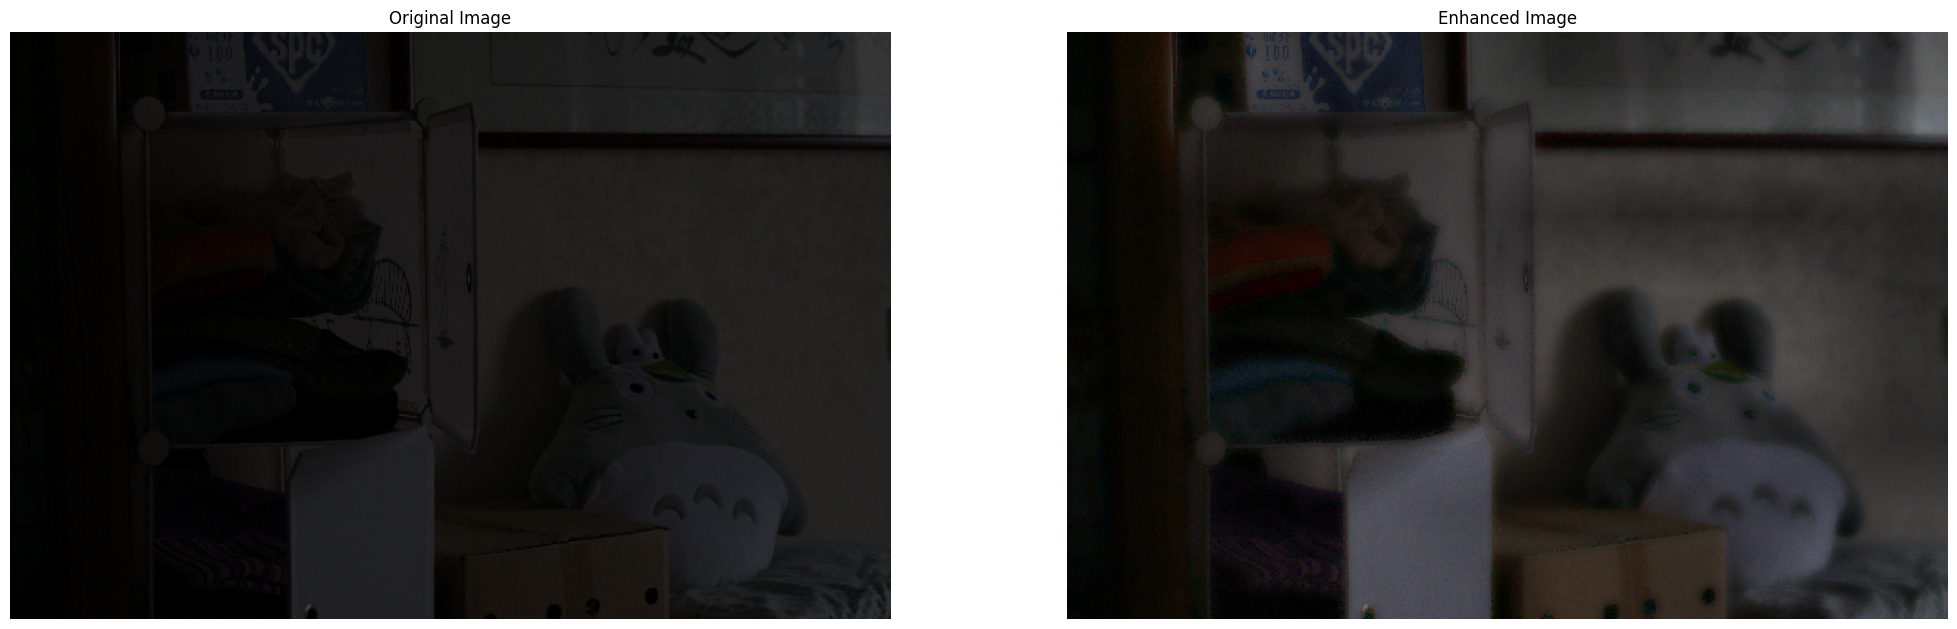

In [83]:
# Step 7: Side-by-side comparison
plt.figure(figsize=(25,13.5))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(enhanced_img)
plt.title("Enhanced Image")
plt.axis('off')